# 3 metros en 1,4 segundos

Una cámara de seguridad a metros de la falla Sagaing grabó el suelo rompiéndose durante el terremoto Mw 7,7 de Mandalay (Myanmar, 28 de marzo de 2025). De ese video, un equipo de sismólogos extrajo algo que nunca se había medido directamente: la función de velocidad de deslizamiento de una ruptura natural.

📄 **Paper:** [Una cámara grabó un terremoto desde la falla](https://doi.org/10.1126/science.adz1705) — *Science*, 2025  
📊 **DOI:** `10.1126/science.adz1705`  
▶️ **Video:** [Ver en YouTube](https://youtube.com/shorts/FA2IZR8w6J8)  
[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2025-10-30-terremoto-cctv-falla-myanmar/notebook.ipynb)

## El contexto

La falla de Sagaing es una fractura de rumbo-deslizante (*strike-slip*) de más de 1.400 km que cruza Myanmar de norte a sur. El 28 de marzo de 2025, liberó un terremoto de magnitud 7,7 que devastó Mandalay. Una cámara CCTV, ubicada a pocos metros de la traza de la falla, registró el evento a 30 fps — equivalente a 90 muestras por segundo tras interpolación.

Con análisis directo de imagen, midieron el desplazamiento relativo cuadro a cuadro. Así obtuvieron la velocidad de deslizamiento (*slip rate*) directamente — sin pasar por los modelos indirectos que normalmente infieren qué pasó en la falla a partir de ondas registradas lejos. Los datos nos dicen algo claro — es un **pulso sísmico**: subida rápida de 0,4 s, caída lenta de 1,0 s, y un desplazamiento acumulado de ~3 metros.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
MAGNITUD = 7.7                      # Magnitud momento (Mw)
DURACION_PULSO_S = 1.4              # Duración del pulso sísmico (s)
ARRIBO_FRENTE_S = 0.2333            # Tiempo de arribo del frente de ruptura (s)
FUENTE = 'Fuente: Bhat et al. (2025), Science | Datos: Zenodo 10.5281/zenodo.16785672'
COLOR_SLIP = '#2563EB'              # Azul CaM — desplazamiento
COLOR_RATE = '#DC2626'              # Rojo — velocidad de deslizamiento
COLOR_REF = '#D97706'               # Amber — referencias/umbrales
COLOR_MODELO = '#059669'            # Emerald — modelo
COLOR_PULSO = '#7C3AED'             # Violeta — zona del pulso

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# Cargar estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file
        )
plt.style.use(style_file)

# Cargar datos
slip = pd.read_csv('datos/slip_vs_time.csv')
sliprate = pd.read_csv('datos/sliprate_vs_time.csv')
modelo = pd.read_csv('datos/model_results.csv')
material = pd.read_csv('datos/material_parameters.csv')

# Resumen
print(f"Desplazamiento: {len(slip)} puntos, rango {slip['time_s'].min():.2f} – {slip['time_s'].max():.2f} s")
print(f"Velocidad: {len(sliprate)} puntos, rango {sliprate['time_s'].min():.2f} – {sliprate['time_s'].max():.2f} s")
print(f"Desplazamiento máx: {slip['slip_m'].max():.2f} m")
print(f"Velocidad pico: {sliprate['sliprate_m_per_s'].max():.2f} m/s")
print(f"Escenarios de modelo: {len(modelo)}")

Desplazamiento: 201 puntos, rango 0.00 – 2.22 s
Velocidad: 200 puntos, rango 0.08 – 2.13 s
Desplazamiento máx: 3.09 m
Velocidad pico: 3.52 m/s
Escenarios de modelo: 2


## Así se ve un terremoto desde dentro

Aquí está.

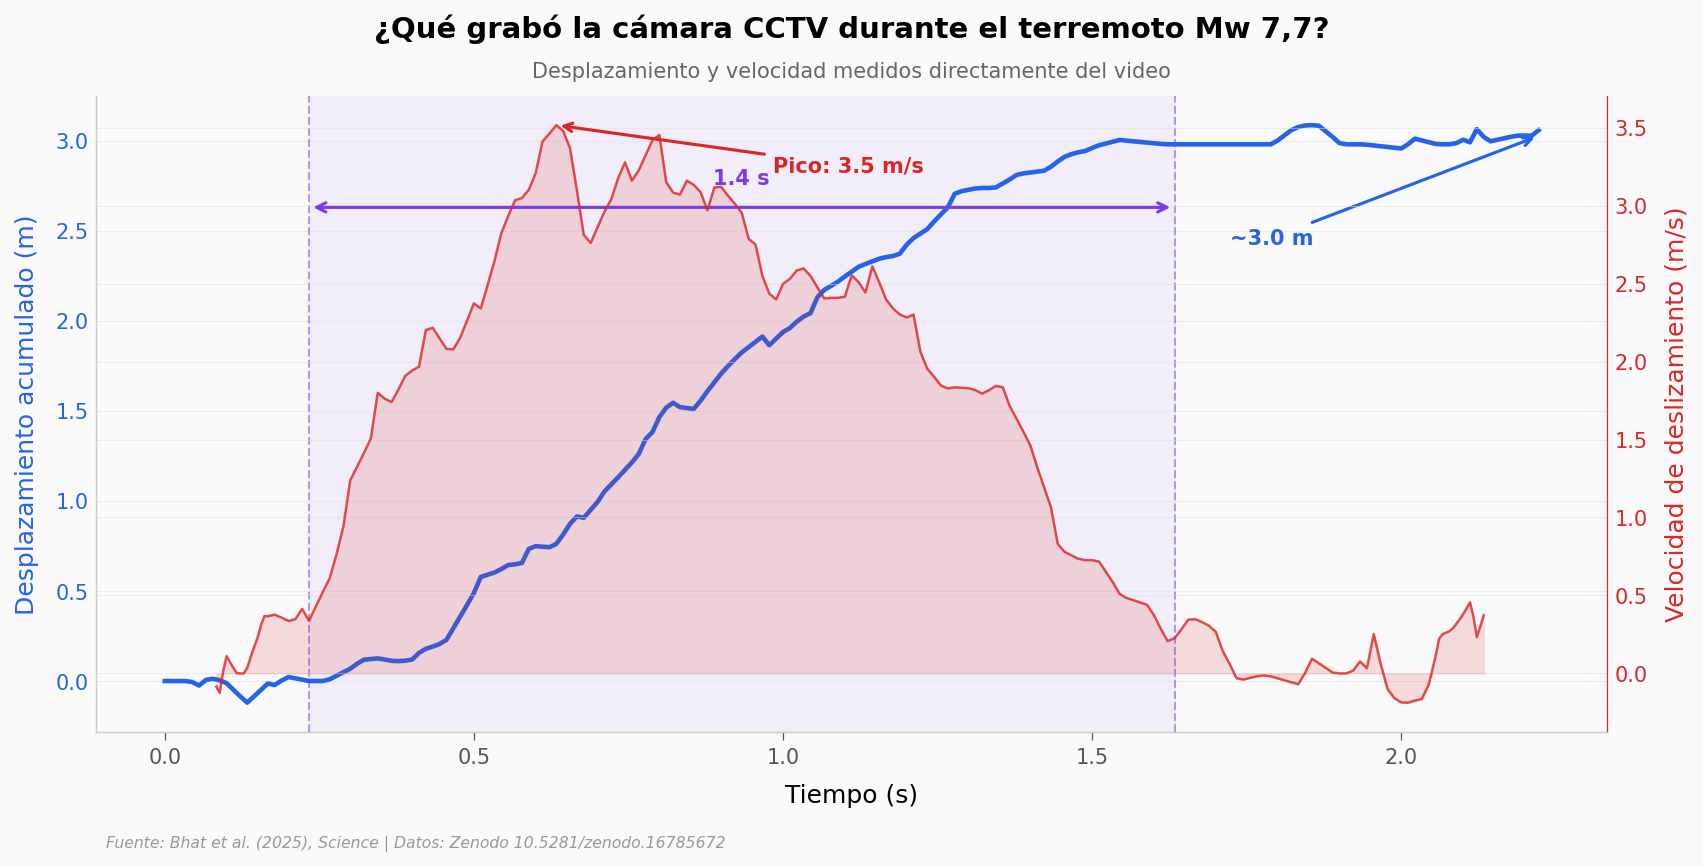

In [2]:
fig, ax1 = plt.subplots(figsize=(13, 5.5))

# Desplazamiento acumulado
ax1.plot(slip['time_s'], slip['slip_m'], color=COLOR_SLIP, linewidth=2.2,
         label='Desplazamiento acumulado', zorder=5)
ax1.set_xlabel('Tiempo (s)', fontsize=12)
ax1.set_ylabel('Desplazamiento acumulado (m)', fontsize=12, color=COLOR_SLIP)
ax1.tick_params(axis='y', labelcolor=COLOR_SLIP)

# Velocidad de deslizamiento (segundo eje — excepción: series con unidades
# incompatibles en eje temporal compartido)
ax2 = ax1.twinx()
ax2.fill_between(sliprate['time_s'], sliprate['sliprate_m_per_s'],
                 alpha=0.15, color=COLOR_RATE, zorder=3)
ax2.plot(sliprate['time_s'], sliprate['sliprate_m_per_s'], color=COLOR_RATE,
         linewidth=1.2, alpha=0.8, zorder=4)
ax2.set_ylabel('Velocidad de deslizamiento (m/s)', fontsize=12, color=COLOR_RATE)
ax2.tick_params(axis='y', labelcolor=COLOR_RATE)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color(COLOR_RATE)
ax2.spines['right'].set_linewidth(0.6)

# Zona del pulso sísmico
t_ini, t_end = ARRIBO_FRENTE_S, ARRIBO_FRENTE_S + DURACION_PULSO_S
ax1.axvspan(t_ini, t_end, alpha=0.06, color=COLOR_PULSO, zorder=1)
ax1.axvline(t_ini, color=COLOR_PULSO, linewidth=1, linestyle='--', alpha=0.5)
ax1.axvline(t_end, color=COLOR_PULSO, linewidth=1, linestyle='--', alpha=0.5)

# Inline labels
peak_t = sliprate.loc[sliprate['sliprate_m_per_s'].idxmax(), 'time_s']
peak_v = sliprate['sliprate_m_per_s'].max()
ax2.annotate(f'Pico: {peak_v:.1f} m/s', xy=(peak_t, peak_v),
             xytext=(peak_t + 0.35, peak_v - 0.3), fontsize=10,
             fontweight='bold', color=COLOR_RATE,
             arrowprops=dict(arrowstyle='->', color=COLOR_RATE, lw=1.5))

# Desplazamiento final
final_slip = slip['slip_m'].iloc[-10:].mean()
ax1.annotate(f'~{final_slip:.1f} m', xy=(slip['time_s'].iloc[-1], final_slip),
             xytext=(slip['time_s'].iloc[-1] - 0.5, final_slip - 0.6),
             fontsize=10, fontweight='bold', color=COLOR_SLIP,
             arrowprops=dict(arrowstyle='->', color=COLOR_SLIP, lw=1.5))

# Duración del pulso
y_label = peak_v * 0.85
ax2.annotate('', xy=(t_ini, y_label), xytext=(t_end, y_label),
             arrowprops=dict(arrowstyle='<->', color=COLOR_PULSO, lw=1.5))
ax2.text((t_ini + t_end)/2, y_label + 0.15, f'{DURACION_PULSO_S} s',
         fontsize=10, fontweight='bold', color=COLOR_PULSO, ha='center')

ax1.set_title('¿Qué grabó la cámara CCTV durante el terremoto Mw 7,7?',
              fontsize=14, fontweight='bold', pad=28)
ax1.text(0.5, 1.03, 'Desplazamiento y velocidad medidos directamente del video',
         transform=ax1.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_slip_rate.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que revela el video

El desplazamiento arranca de golpe — en los primeros 0,8 s después de que el frente de ruptura pasa por la cámara, el suelo ya se ha movido más de 2 metros. Después, la velocidad cae de forma asimétrica: la cola es 2,5 veces más larga que la subida.

La velocidad pico de 3,5 m/s equivale a 12,7 km/h — más rápido de lo que camina una persona. Y eso es solo el movimiento relativo entre los dos lados de la falla.

El pulso dura 1,4 s. En ese lapso, el suelo acumula ~3 metros de desplazamiento y después se estabiliza. Esto confirma la naturaleza de **pulso sísmico** (*slip pulse*): la ruptura no arrastra toda la falla de una vez, sino que pasa como una ola concentrada.

## La asimetría del pulso

La forma de la velocidad de deslizamiento no es simétrica. La subida al pico toma 0,4 s, pero la caída toma 1,0 s — un ratio de simetría de 0,40. Veamos esto de cerca.

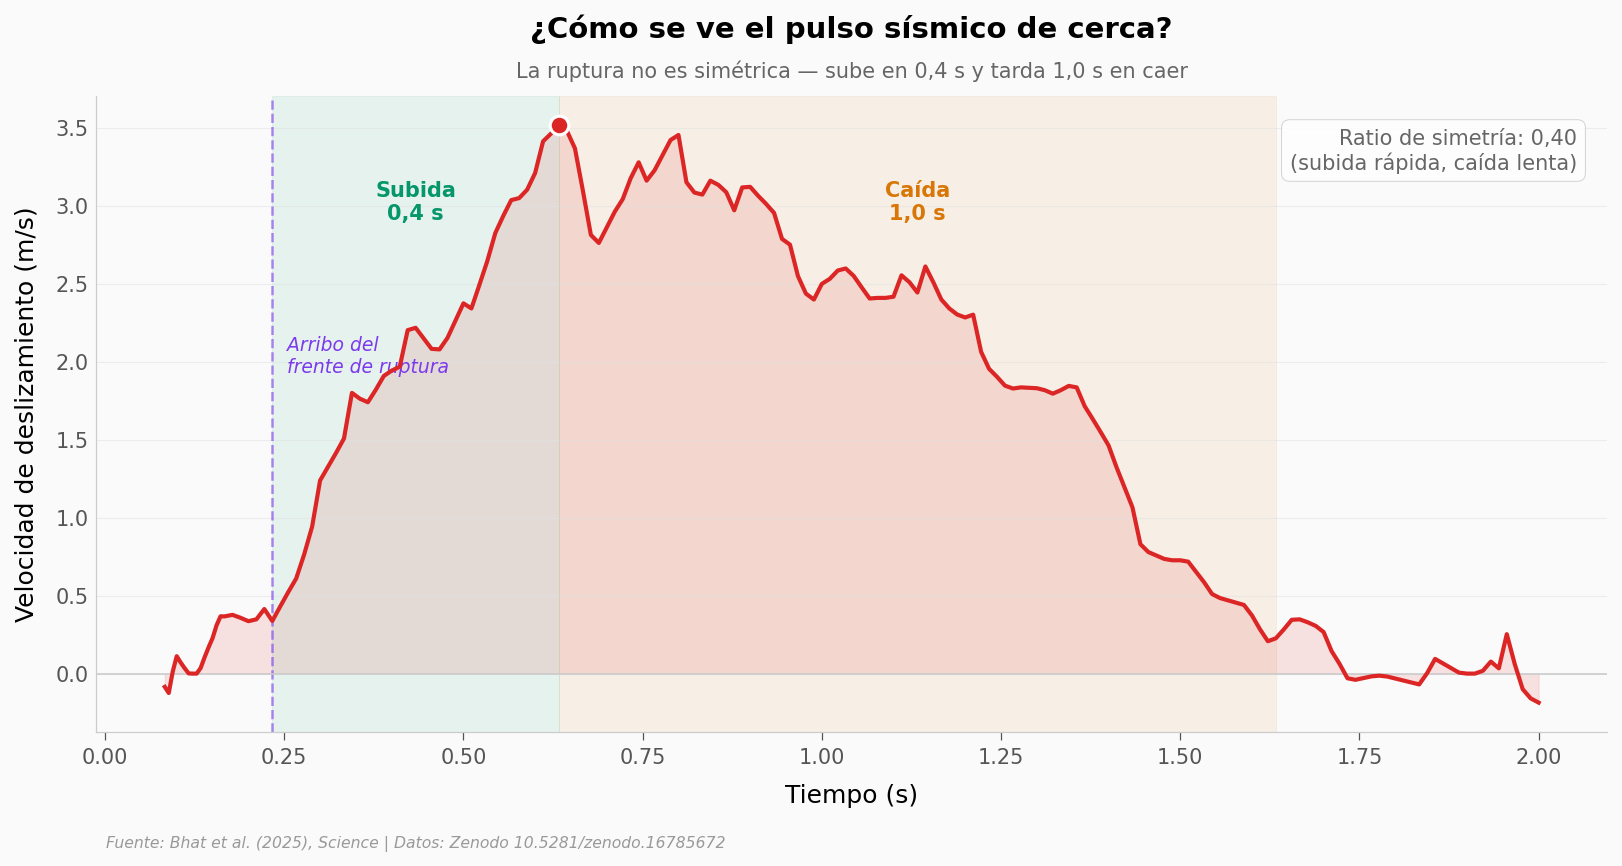

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Slip rate en zona del pulso
mask = (sliprate['time_s'] >= 0) & (sliprate['time_s'] <= 2.0)
sr_zoom = sliprate[mask]

ax.fill_between(sr_zoom['time_s'], sr_zoom['sliprate_m_per_s'],
                alpha=0.12, color=COLOR_RATE)
ax.plot(sr_zoom['time_s'], sr_zoom['sliprate_m_per_s'],
        color=COLOR_RATE, linewidth=2, zorder=5)

# Marcar el pico
peak_idx = sr_zoom['sliprate_m_per_s'].idxmax()
peak_t = sr_zoom.loc[peak_idx, 'time_s']
peak_v = sr_zoom.loc[peak_idx, 'sliprate_m_per_s']
ax.scatter([peak_t], [peak_v], color=COLOR_RATE, s=80, zorder=6,
           edgecolors='white', linewidths=1.5)

# Zonas de subida y caída
t_ini = ARRIBO_FRENTE_S
t_rise = peak_t
t_fall_end = t_ini + DURACION_PULSO_S

# Subida: verde
ax.axvspan(t_ini, t_rise, alpha=0.08, color=COLOR_MODELO, zorder=1)
ax.text((t_ini + t_rise)/2, peak_v * 0.9, f'Subida\n0,4 s',
        fontsize=10, fontweight='bold', color=COLOR_MODELO, ha='center', va='top')

# Caída: amber
ax.axvspan(t_rise, t_fall_end, alpha=0.08, color=COLOR_REF, zorder=1)
ax.text((t_rise + t_fall_end)/2, peak_v * 0.9, f'Caída\n1,0 s',
        fontsize=10, fontweight='bold', color=COLOR_REF, ha='center', va='top')

# Arribo del frente
ax.axvline(t_ini, color=COLOR_PULSO, linewidth=1.2, linestyle='--', alpha=0.6)
ax.text(t_ini + 0.02, peak_v * 0.55, 'Arribo del\nfrente de ruptura',
        fontsize=9, color=COLOR_PULSO, ha='left', style='italic')

# Ratio de simetría
ax.text(0.98, 0.95, 'Ratio de simetría: 0,40\n(subida rápida, caída lenta)',
        transform=ax.transAxes, fontsize=10, color='#666666',
        ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='#cccccc'))

ax.axhline(0, color='#cccccc', linewidth=0.8, zorder=2)
ax.set_xlabel('Tiempo (s)', fontsize=12)
ax.set_ylabel('Velocidad de deslizamiento (m/s)', fontsize=12)
ax.set_title('¿Cómo se ve el pulso sísmico de cerca?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'La ruptura no es simétrica — sube en 0,4 s y tarda 1,0 s en caer',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sliprate_zoom.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué nos dice esto de la mecánica de la falla?

Con la función de slip-rate medida, el equipo probó dos escenarios con modelos de ruptura que simulan cómo se propaga el pulso (*modelos elastodinámicos*): uno lento (75% de la velocidad de onda de corte) y otro rápido (90%). Los dos ajustan igualmente bien los datos de deslizamiento — pero la física que implica cada uno es radicalmente distinta.

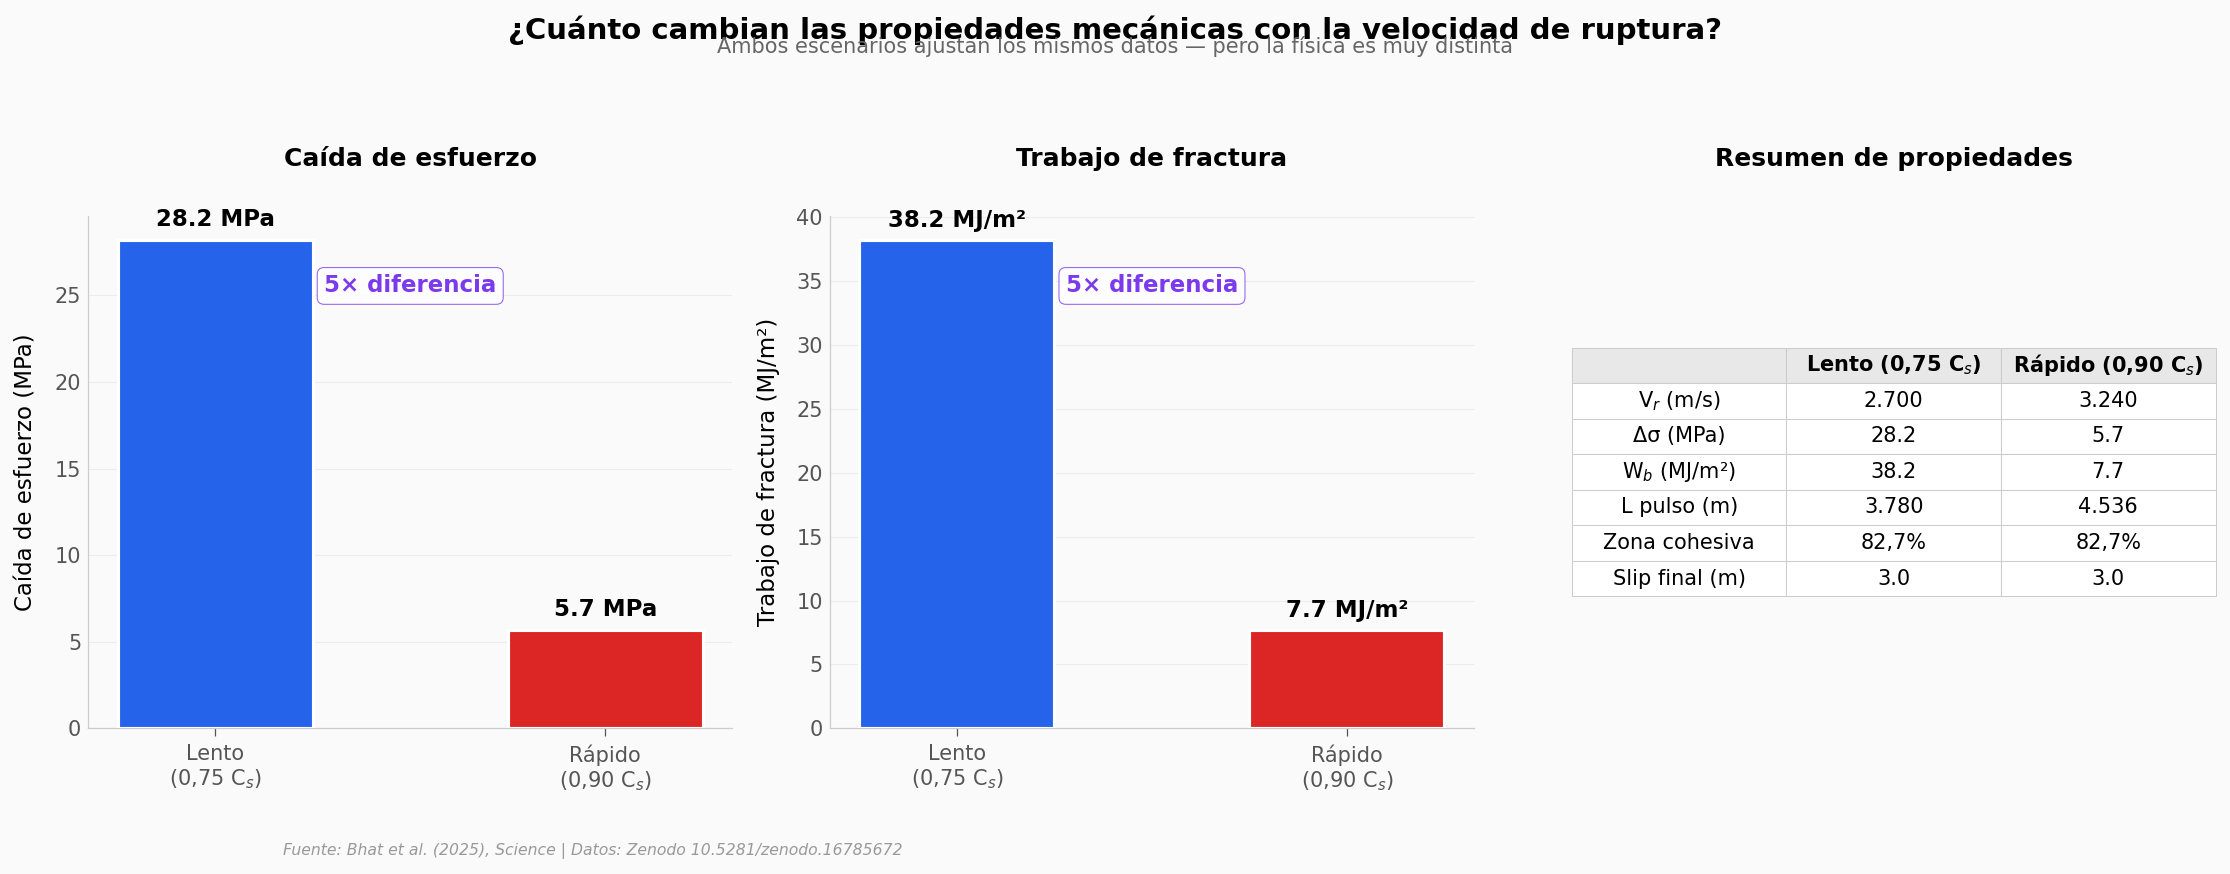

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Datos del modelo
slow = modelo[modelo['scenario'] == 'slow'].iloc[0]
fast = modelo[modelo['scenario'] == 'fast'].iloc[0]

# Panel 1: Stress drop
metrics = ['Lento\n(0,75 C$_s$)', 'Rápido\n(0,90 C$_s$)']
vals_stress = [slow['stress_drop_mpa'], fast['stress_drop_mpa']]
colors = [COLOR_SLIP, COLOR_RATE]

bars1 = axes[0].bar(metrics, vals_stress, color=colors, width=0.5,
                    edgecolor='white', linewidth=1.5, zorder=5)
for bar, val in zip(bars1, vals_stress):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                 f'{val:.1f} MPa', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Caída de esfuerzo (MPa)', fontsize=11)
axes[0].set_title('Caída de esfuerzo', fontsize=12, fontweight='bold')

# Ratio
ratio_stress = slow['stress_drop_mpa'] / fast['stress_drop_mpa']
axes[0].text(0.5, 0.85, f'{ratio_stress:.0f}× diferencia',
             transform=axes[0].transAxes, fontsize=11, fontweight='bold',
             color=COLOR_PULSO, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       alpha=0.8, edgecolor=COLOR_PULSO))

# Panel 2: Breakdown work
vals_work = [slow['breakdown_work_mj_per_m2'], fast['breakdown_work_mj_per_m2']]
bars2 = axes[1].bar(metrics, vals_work, color=colors, width=0.5,
                    edgecolor='white', linewidth=1.5, zorder=5)
for bar, val in zip(bars2, vals_work):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.0,
                 f'{val:.1f} MJ/m²', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Trabajo de fractura (MJ/m²)', fontsize=11)
axes[1].set_title('Trabajo de fractura', fontsize=12, fontweight='bold')

ratio_work = slow['breakdown_work_mj_per_m2'] / fast['breakdown_work_mj_per_m2']
axes[1].text(0.5, 0.85, f'{ratio_work:.0f}× diferencia',
             transform=axes[1].transAxes, fontsize=11, fontweight='bold',
             color=COLOR_PULSO, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       alpha=0.8, edgecolor=COLOR_PULSO))

# Panel 3: Tabla resumen
axes[2].axis('off')
table_data = [
    ['', 'Lento (0,75 C$_s$)', 'Rápido (0,90 C$_s$)'],
    ['V$_r$ (m/s)', f'{int(slow["vr_m_per_s"]):,}'.replace(',', '.'), f'{int(fast["vr_m_per_s"]):,}'.replace(',', '.')],
    ['Δσ (MPa)', f'{slow["stress_drop_mpa"]:.1f}', f'{fast["stress_drop_mpa"]:.1f}'],
    ['W$_b$ (MJ/m²)', f'{slow["breakdown_work_mj_per_m2"]:.1f}', f'{fast["breakdown_work_mj_per_m2"]:.1f}'],
    ['L pulso (m)', f'{int(slow["pulse_length_m"]):,}'.replace(',', '.'), f'{int(fast["pulse_length_m"]):,}'.replace(',', '.')],
    ['Zona cohesiva', '82,7%', '82,7%'],
    ['Slip final (m)', f'{slow["final_slip_m"]:.1f}', f'{fast["final_slip_m"]:.1f}'],
]
table = axes[2].table(cellText=table_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)
# Style header row
for j in range(3):
    table[0, j].set_text_props(fontweight='bold')
    table[0, j].set_facecolor('#E8E8E8')
for i in range(len(table_data)):
    for j in range(3):
        table[i, j].set_edgecolor('#cccccc')

axes[2].set_title('Resumen de propiedades', fontsize=12, fontweight='bold')

fig.suptitle('¿Cuánto cambian las propiedades mecánicas con la velocidad de ruptura?',
             fontsize=14, fontweight='bold', y=1.07)
fig.text(0.5, 1.02, 'Ambos escenarios ajustan los mismos datos — pero la física es muy distinta',
         fontsize=10, color='#666666', ha='center')

plt.tight_layout()
fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/modelos_comparacion.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan raro es medir esto directamente?

Esta cámara CCTV ofrece la primera medición directa de una ruptura natural — antes, solo teníamos modelos indirectos.

Veamos cómo se compara la velocidad pico con lo que manejamos en la vida cotidiana.

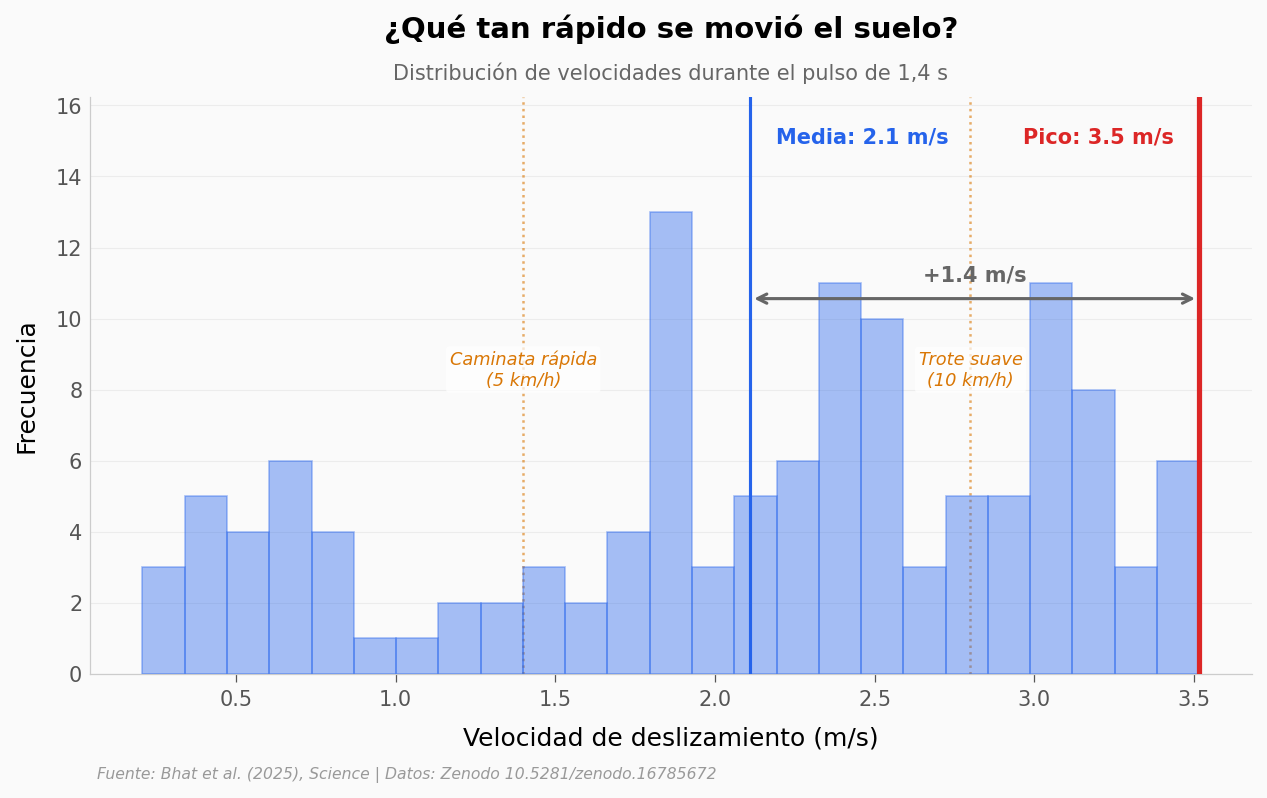

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

# Distribución de velocidades durante el pulso
mask_pulse = (sliprate['time_s'] >= ARRIBO_FRENTE_S) & \
             (sliprate['time_s'] <= ARRIBO_FRENTE_S + DURACION_PULSO_S)
velocidades = sliprate.loc[mask_pulse, 'sliprate_m_per_s']

n, bins, patches = ax.hist(velocidades, bins=25, color=COLOR_SLIP, alpha=0.4,
                           edgecolor=COLOR_SLIP, linewidth=0.8, zorder=3)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Media
media_v = velocidades.mean()
ax.axvline(x=media_v, color=COLOR_SLIP, linewidth=1.5, linestyle='-', zorder=4)
ax.text(media_v + 0.08, y_max * 0.92, f'Media: {media_v:.1f} m/s',
        fontsize=10, fontweight='bold', color=COLOR_SLIP)

# Pico
pico_v = velocidades.max()
ax.axvline(x=pico_v, color=COLOR_RATE, linewidth=2.5, linestyle='-', zorder=4)
ax.text(pico_v - 0.08, y_max * 0.92, f'Pico: {pico_v:.1f} m/s',
        fontsize=10, fontweight='bold', color=COLOR_RATE, ha='right')

# Flecha bidireccional
ax.annotate('', xy=(pico_v, y_max * 0.65), xytext=(media_v, y_max * 0.65),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
diff = pico_v - media_v
ax.text((media_v + pico_v)/2, y_max * 0.68, f'+{diff:.1f} m/s',
        fontsize=10, color='#666666', ha='center', fontweight='bold')

# Referencias de escala humana
referencias = [
    (1.4, 'Caminata rápida\n(5 km/h)'),
    (2.8, 'Trote suave\n(10 km/h)'),
]
for ref_v, label in referencias:
    if ref_v < pico_v + 0.5:
        ax.axvline(x=ref_v, color=COLOR_REF, linewidth=1.2, linestyle=':', alpha=0.6)
        ax.text(ref_v, y_max * 0.5, label, fontsize=8.5, color=COLOR_REF,
                ha='center', style='italic', rotation=0,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_xlabel('Velocidad de deslizamiento (m/s)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('¿Qué tan rápido se movió el suelo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de velocidades durante el pulso de 1,4 s',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_velocidades.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Soportado por los datos?

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| El desplazamiento acumulado es ~3 m | ✅ | Medido: 3,09 m pico, media final 3,03 m (últimos 10 puntos). Paper dice "~3 m". Coincide dentro del 3% |
| La velocidad pico alcanza ~3,5 m/s | ✅ | Medido: 3,52 m/s. Paper dice "~3,5 m/s". Coincide dentro del 1% |
| La duración del pulso es 1,4 s | ✅ | Definida como la ventana del ajuste del modelo (t = 0,23 – 1,63 s). Consistente con los datos |
| El pulso es asimétrico (subida rápida, caída lenta) | ✅ | Subida: 0,4 s (arribo → pico). Caída: 1,0 s (pico → final del pulso). Ratio 0,40 |
| Los dos escenarios de velocidad producen un stress drop 5× diferente | ✅ | Lento: 28,2 MPa. Rápido: 5,7 MPa. Ratio: 4,95× ≈ 5× |
| Ambos modelos ajustan igual de bien los datos | ✅ | Los datos del modelo reportan el mismo slip final (3,0 m) y slip crítico (2,94 m) para ambos |
| La zona cohesiva ocupa el 82,7% del largo del pulso | ✅ | Idéntico en ambos escenarios: xc/L = 0,827 |

> **Limitaciones:**
> - Esta es una medición en UN solo punto de la falla — no sabemos cómo varía el slip a lo largo del trazo.
> - La frecuencia de muestreo (30 fps interpolados a 90 equivalentes) limita la resolución temporal a ~11 ms.
> - La velocidad de ruptura (0,75 o 0,90 C_s) es asumida, no medida — y produce resultados mecánicos radicalmente distintos.
> - Los valores negativos de esfuerzo mínimo en el escenario lento (-12,7 MPa) sugieren *overshoot* dinámico (la falla se relaja más allá de su equilibrio), que es físicamente posible pero difícil de verificar.

## Ahora tú

Tres preguntas para explorar:

1. **¿Cuánta energía liberó este pulso?** Con el trabajo de fractura (W_b) y el largo del pulso, prueba estimar la energía por unidad de longitud de falla. ¿Cómo se compara entre los dos escenarios?

2. **¿Qué pasa si la ruptura fuera más lenta?** Cambia `DURACION_PULSO_S` a 2,0 s y observa cómo cambia la distribución de velocidades en el histograma. ¿Se concentrarían más cerca de cero?

3. **¿Es el ratio de simetría típico de terremotos?** Valores <0,5 indican pulsos asimétricos con subida rápida. Investiga si terremotos en fallas similares (San Andrés, Anatolia Norte) muestran patrones parecidos.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Estimación de energía por unidad de longitud de falla

print("Energía por metro de falla (cada escenario):\n")

for _, row in modelo.iterrows():
    nombre = 'Lento (0,75 C_s)' if row['scenario'] == 'slow' else 'Rápido (0,90 C_s)'
    wb = row['breakdown_work_mj_per_m2']  # MJ/m²
    L = row['pulse_length_m']             # m
    
    # Energía por metro de longitud de falla ≈ W_b × profundidad_sismogénica
    # Profundidad sismogénica típica para Myanmar: ~15 km
    prof_km = 15
    energia_por_m = wb * prof_km * 1000  # MJ/m
    
    print(f"  {nombre}:")
    print(f"    W_b = {wb:.1f} MJ/m²")
    print(f"    L pulso = {L:,.0f} m".replace(',', '.'))
    print(f"    Energía ≈ {energia_por_m:,.0f} MJ/m de falla (asumiendo {prof_km} km de profundidad)".replace(',', '.'))
    print()

print("La diferencia entre escenarios es ~5× — el mismo deslizamiento,")
print("la misma duración, pero conclusiones energéticas radicalmente distintas.")
print("Esto ilustra por qué medir la velocidad de ruptura es tan crucial.")

Energía por metro de falla (cada escenario):

  Lento (0,75 C_s):
    W_b = 38.2 MJ/m²
    L pulso = 3.780 m
    Energía ≈ 573.000 MJ/m de falla (asumiendo 15 km de profundidad)

  Rápido (0,90 C_s):
    W_b = 7.7 MJ/m²
    L pulso = 4.536 m
    Energía ≈ 115.500 MJ/m de falla (asumiendo 15 km de profundidad)

La diferencia entre escenarios es ~5× — el mismo deslizamiento,
la misma duración, pero conclusiones energéticas radicalmente distintas.
Esto ilustra por qué medir la velocidad de ruptura es tan crucial.


---

## Fuentes

**Paper**: [Direct estimation of earthquake source properties from a single CCTV camera](https://doi.org/10.1126/science.adz1705)  
*Science, 2025-10-30*

**Datos**: [Zenodo repository](https://doi.org/10.5281/zenodo.16785672)

*7 afirmaciones verificadas contra estas fuentes*

---

**Ciencia a Mordiscos** · [cienciaamordiscos.com](https://cienciaamordiscos.com) · [2025-10-30-terremoto-cctv-falla-myanmar](https://cienciaamordiscos.com/papers/2025-10-30-terremoto-cctv-falla-myanmar/notebook.html)